In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu, pearsonr

import pickle

In [3]:
data_path = '/work/model_myocardial_infarction/dataset/processed_data_v2.csv'
df = pd.read_csv(data_path)

/tmp/ipykernel_109/1085862606.py:2: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


In [4]:
df.head()

,PHYSHLTH,MENTHLTH,POORHLTH,PRIMINS2,PERSDOC3,MEDCOST1,CHECKUP1,CVDSTRK3,CHCSCNC1,CHCOCNC1,...,_INCOMG1,_SMOKER3,_CURECI3,_LCSYSMK,_LCSYQTS,DRNKANY6,_RFBING6,_DRNKWK3,_RFDRHV9,_ismale
0,2.0,NaN,NaN,Medicare,More than one,No,Within 1,No,Yes,No,...,Unknown,Non Smoker,Not User,NaN,NaN,No,Yes,5.397605e-79,Yes,0
1,NaN,NaN,NaN,Medicare,One,No,Within 1,No,No,No,...,"$200,000 or more",Former Smoker,Not User,2.0,53.0,No,Yes,5.397605e-79,Yes,1
2,30.0,NaN,1.0,Employer or union plan,No,Yes,5 or more,No,No,No,...,Unknown,Everyday Smoker,Not User,45.0,NaN,Yes,No,1.400000e+03,Yes,1
3,NaN,NaN,NaN,Medicare,One,No,Within 1,No,Yes,No,...,"$35,000 to < $50,000",Non Smoker,Not User,NaN,NaN,No,Yes,5.397605e-79,Yes,1
4,NaN,NaN,NaN,Medicaid,One,No,Within 1,No,No,No,...,"$15,000 to < $25,000",Non Smoker,Not User,NaN,NaN,No,Yes,5.397605e-79,Yes,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452464 entries, 0 to 452463
Data columns (total 73 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   PHYSHLTH  176477 non-null  float64
 1   MENTHLTH  177534 non-null  float64
 2   POORHLTH  124272 non-null  float64
 3   PRIMINS2  452464 non-null  object 
 4   PERSDOC3  452464 non-null  object 
 5   MEDCOST1  452464 non-null  object 
 6   CHECKUP1  452464 non-null  object 
 7   CVDSTRK3  452464 non-null  object 
 8   CHCSCNC1  452464 non-null  object 
 9   CHCOCNC1  452464 non-null  object 
 10  CHCCOPD3  452464 non-null  object 
 11  ADDEPEV3  452464 non-null  object 
 12  CHCKDNY2  452464 non-null  object 
 13  HAVARTH4  452464 non-null  object 
 14  DIABETE4  452464 non-null  object 
 15  MARITAL   452464 non-null  object 
 16  VETERAN3  452464 non-null  object 
 17  PREGNANT  452464 non-null  object 
 18  DEAF      452464 non-null  object 
 19  BLIND     452464 non-null  object 
 20  DECI

In [6]:
df.describe()

,PHYSHLTH,MENTHLTH,POORHLTH,LCSFIRST,LCSNUMCG,AVEDRNK4,MAXDRNKS,SSBSUGR2,_TOTINDA,_MICHD,_AGEG5YR,HTIN4,_BMI5,_LCSYSMK,_LCSYQTS,_DRNKWK3,_ismale
count,176477.000000,177534.000000,124272.000000,153566.000000,150795.000000,206225.000000,2.025080e+05,60424.000000,451270.000000,452464.000000,452464.000000,421325.000000,410281.000000,1.498710e+05,119217.000000,4.066030e+05,452464.000000
mean,11.432430,11.013862,11.286991,17.792168,15.047581,2.257554,3.383229e+00,0.772607,0.768746,0.093572,7.764786,67.050600,2855.161969,2.440247e+01,21.869280,2.795412e+02,0.474712
std,10.920214,10.063311,10.273144,5.098642,12.402441,2.410996,3.499086e+00,3.497152,0.421635,0.291233,3.735420,4.204138,657.777866,1.644506e+01,17.479259,8.940065e+02,0.499361
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,5.397605e-79,0.033333,0.000000,0.000000,1.000000,36.000000,1200.000000,5.397605e-79,-30.000000,5.397605e-79,0.000000
25%,2.000000,3.000000,3.000000,15.000000,7.000000,1.000000,1.000000e+00,0.066667,1.000000,0.000000,5.000000,64.000000,2414.000000,1.000000e+01,6.000000,5.397605e-79,0.000000
50%,6.000000,7.000000,7.000000,17.000000,10.000000,2.000000,2.000000e+00,0.166667,1.000000,0.000000,8.000000,67.000000,2744.000000,2.200000e+01,19.000000,2.300000e+01,0.000000
75%,20.000000,15.000000,20.000000,19.000000,20.000000,3.000000,4.000000e+00,1.000000,1.000000,0.000000,11.000000,70.000000,3175.000000,3.700000e+01,36.000000,2.330000e+02,1.000000
max,30.000000,30.000000,30.000000,99.000000,490.000000,76.000000,7.600000e+01,99.000000,1.000000,1.000000,14.000000,95.000000,9984.000000,9.000000e+01,83.000000,5.320000e+04,1.000000


In [7]:
# Parameters
path = '/work/model_myocardial_infarction/dataset/processed_data_v2.csv'
df = pd.read_csv(path)
TARGET = '_MICHD'
CHUNK  = 9
P_THRESHOLD = 0.05
CV_THRESHOLD = 0.09 #binary
CORR_THRESHOLD = 0.1 #continuous

/tmp/ipykernel_109/2910162563.py:3: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [8]:
# Extract Multi-class Categorical Columns
# This catches string/object types AND numeric columns with low unique values
categorical_cols = [
    c for c in df.columns 
    if c != TARGET 
    and (df[c].dtype == 'object' or df[c].dtype.name == 'category' or df[c].nunique() < 10)
]

# Extract True Continuous Columns
# Only counts numeric columns with a high number of unique values
continuous_cols = [
    c for c in df.select_dtypes("number").columns 
    if c != TARGET 
    and c not in categorical_cols
]

In [9]:
print(f"Number of all columns: {len(df.columns)}")
print(f"Number of categorical feature columns: {len(categorical_cols)}")
print(f"Number of continuous feature columns: {len(continuous_cols)}")

Number of all columns: 73
Number of categorical feature columns: 58
Number of continuous feature columns: 14


In [10]:
# Helper Functions
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def plot_chunks(cols, plot_fn, suptitle_fmt, cols_per_row=3):
    chunks = [cols[i:i+CHUNK] for i in range(0, len(cols), CHUNK)]
    for batch, chunk in enumerate(chunks, 1):
        n_cols = min(cols_per_row, len(chunk))
        n_rows = (len(chunk) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(n_cols * 4.5, n_rows * 3.5))
        axes = np.array(axes).flatten()
        for j, col in enumerate(chunk):
            plot_fn(col, j, axes[j])
        for k in range(len(chunk), len(axes)):
            axes[k].set_visible(False)
        fig.suptitle(suptitle_fmt.format(batch, len(chunks)),
                     y=1.01, fontsize=12)
        plt.tight_layout(); plt.show()

### Significance Testing & Effect Size Estimation on Categorical Variables vs\. \_MICHD

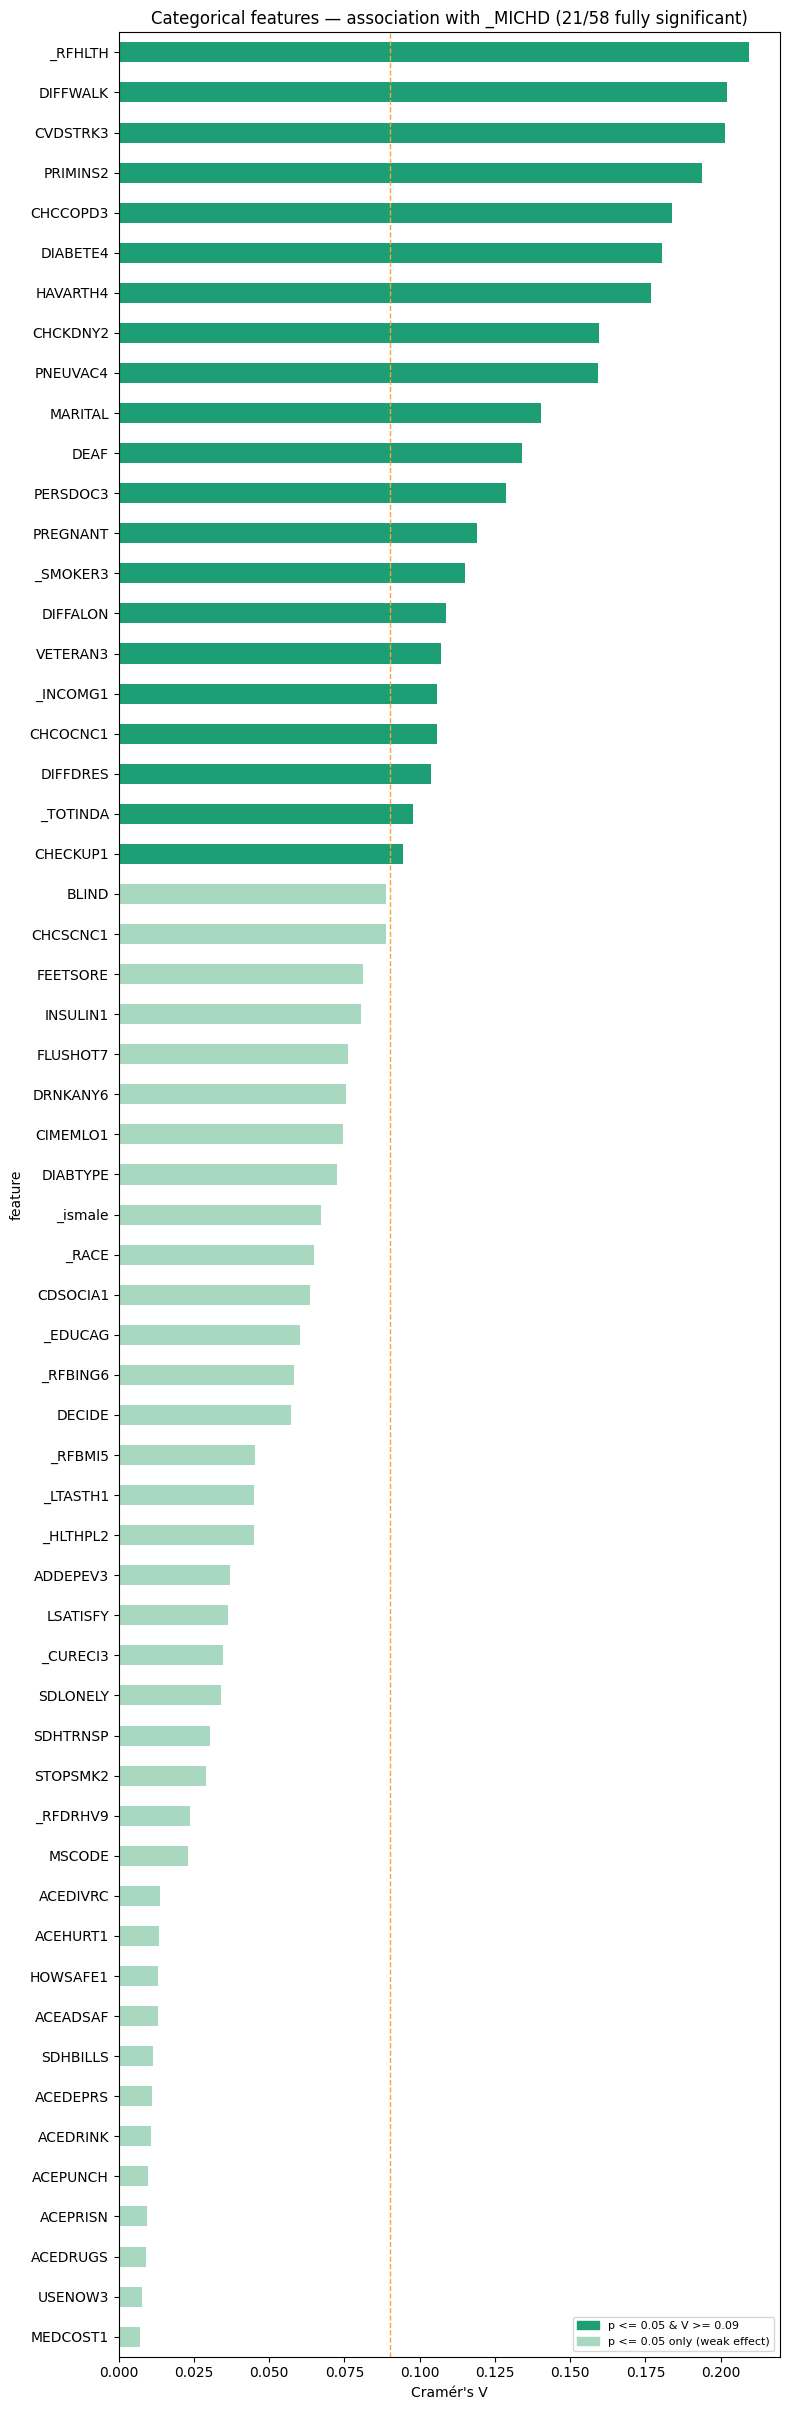

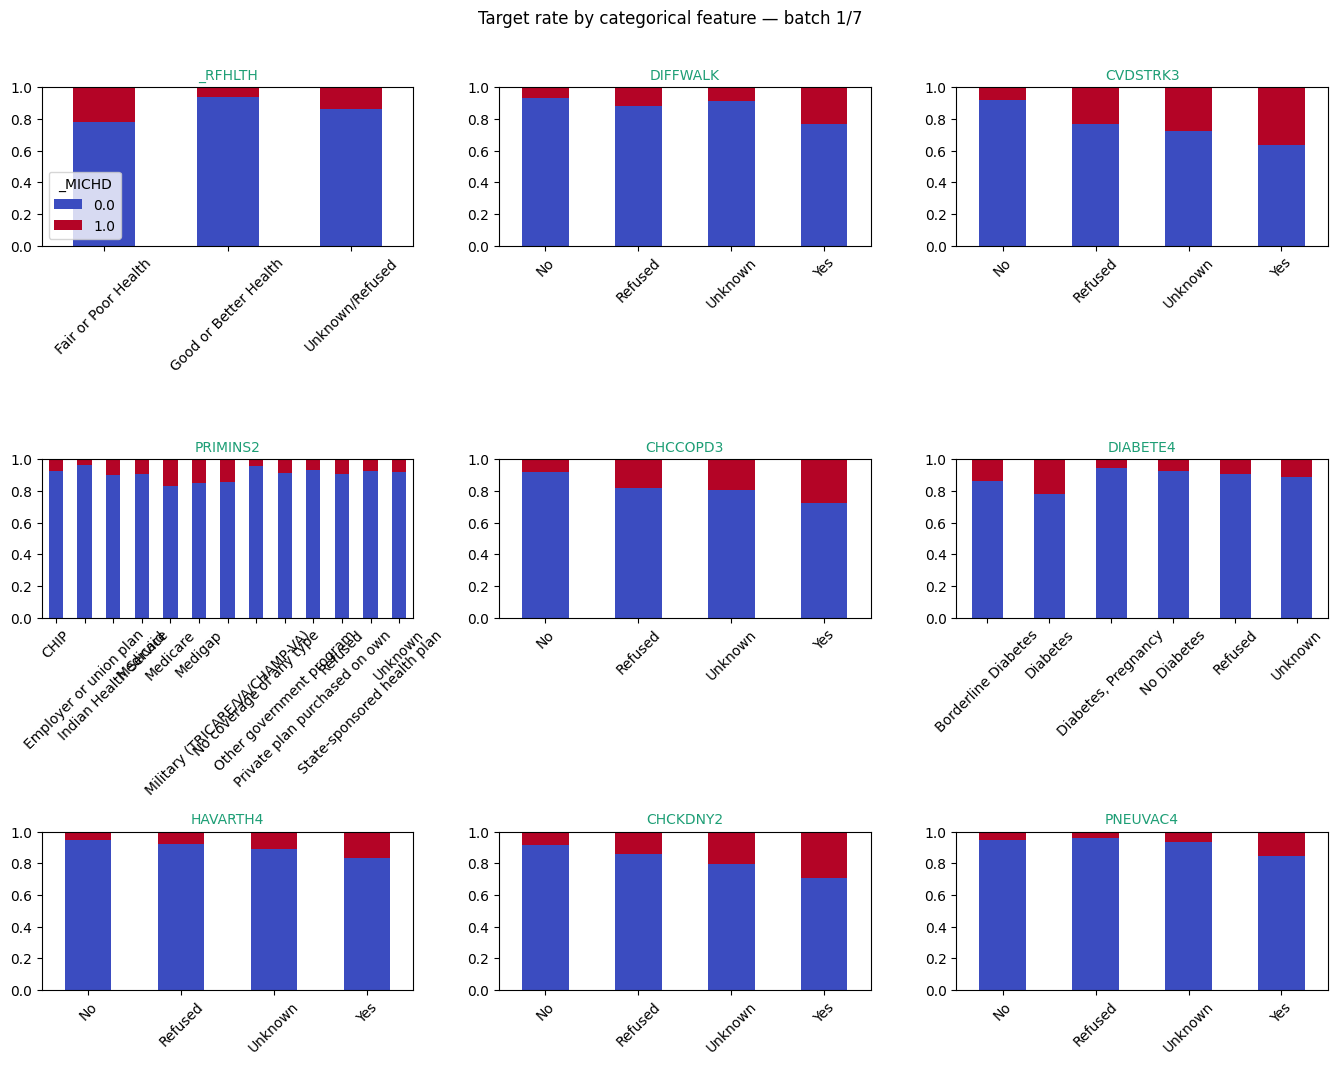

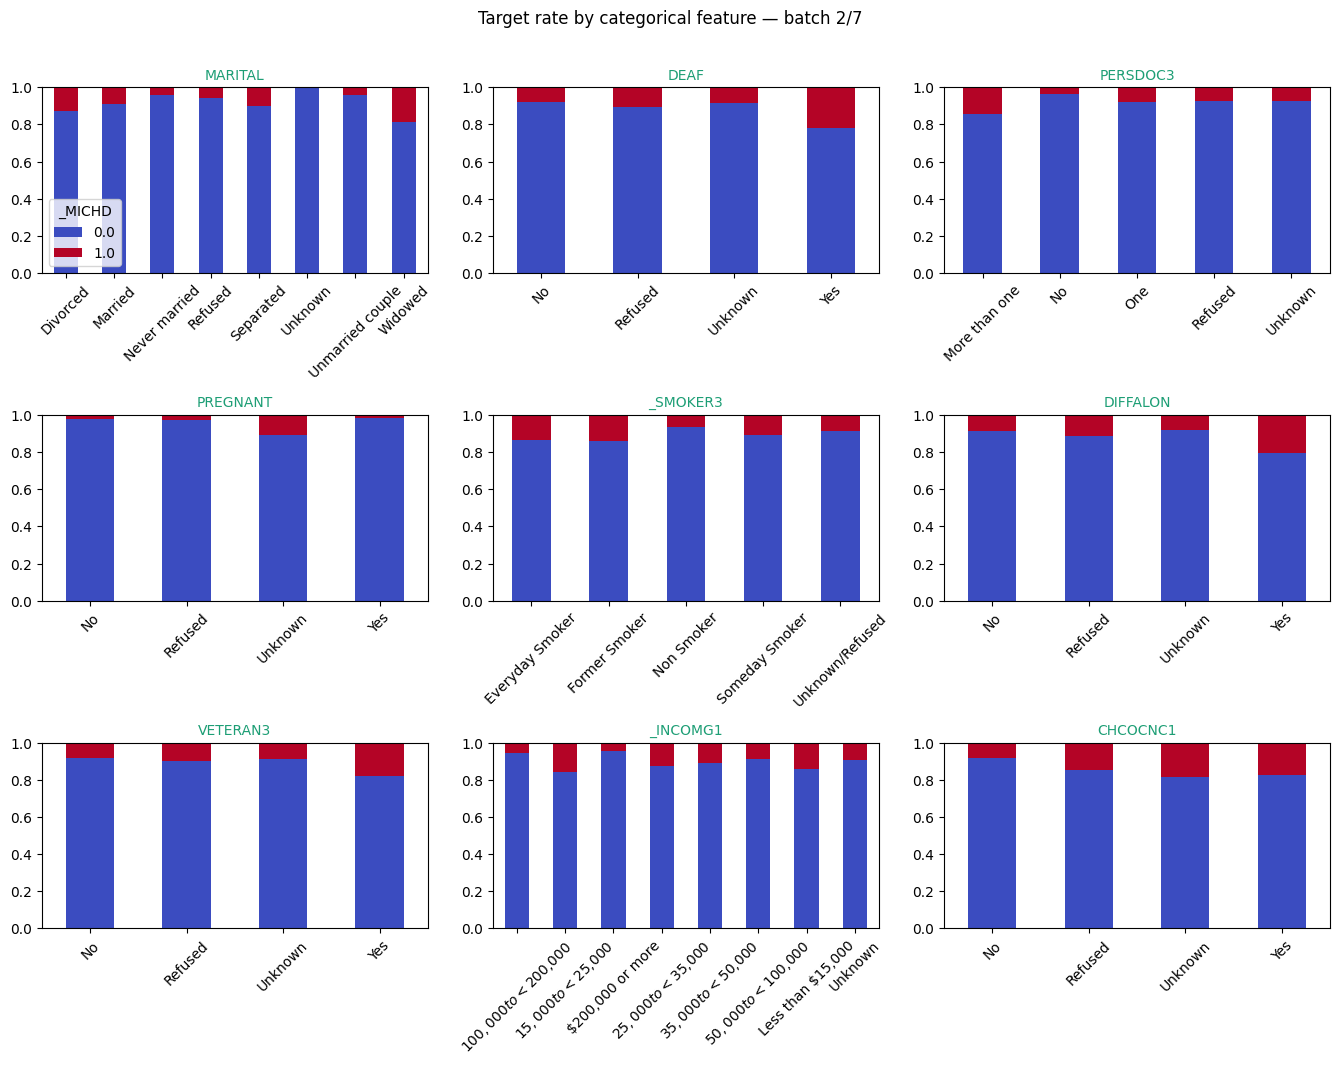

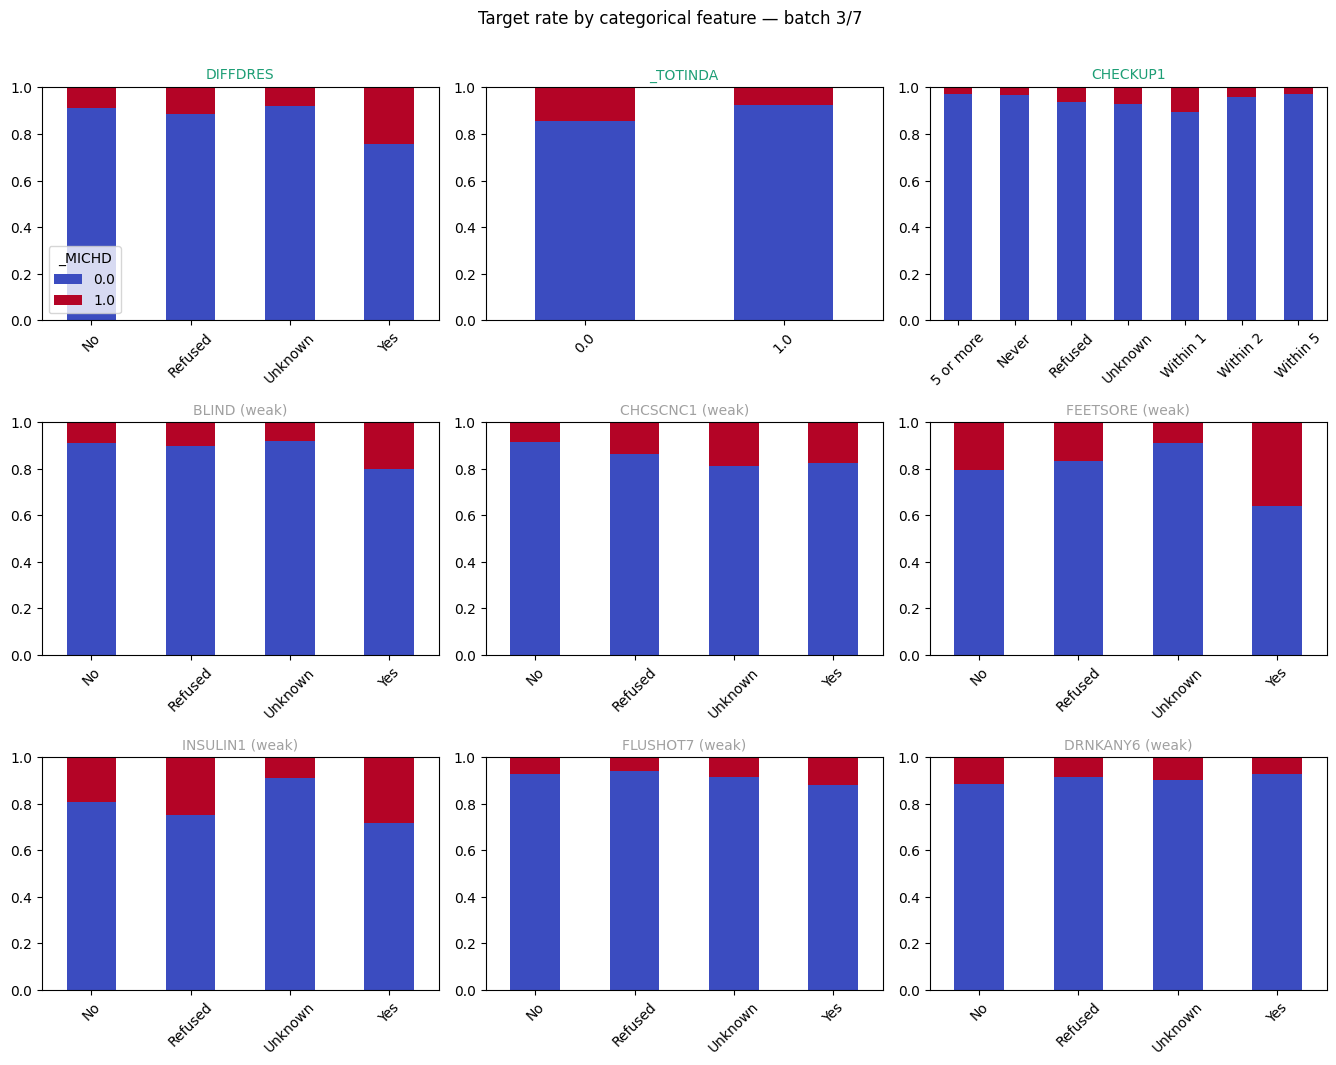

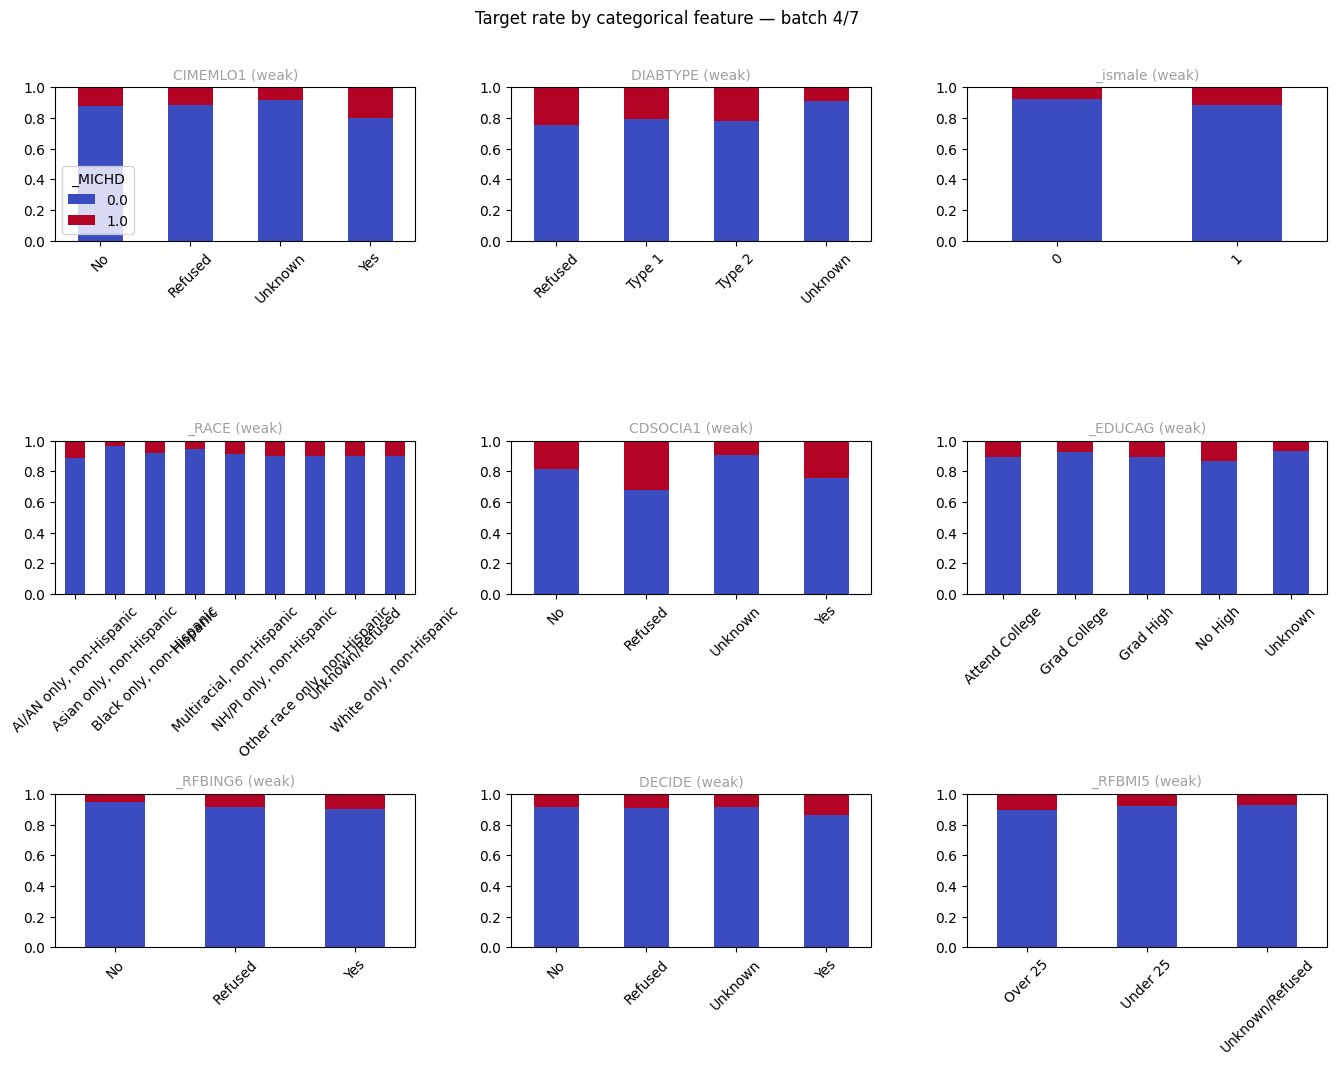

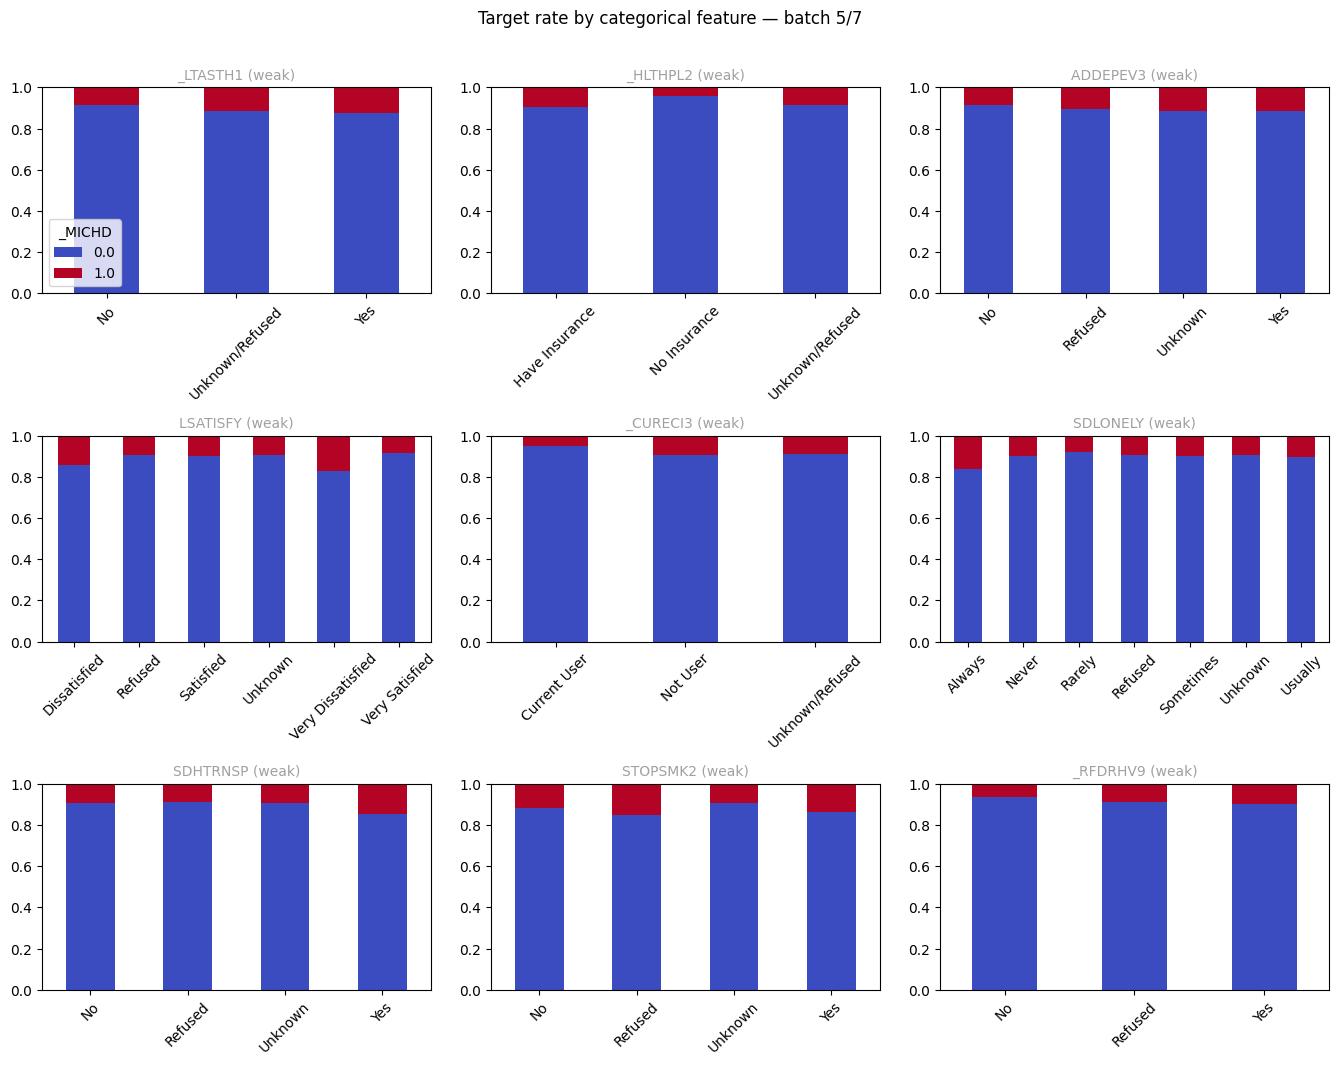

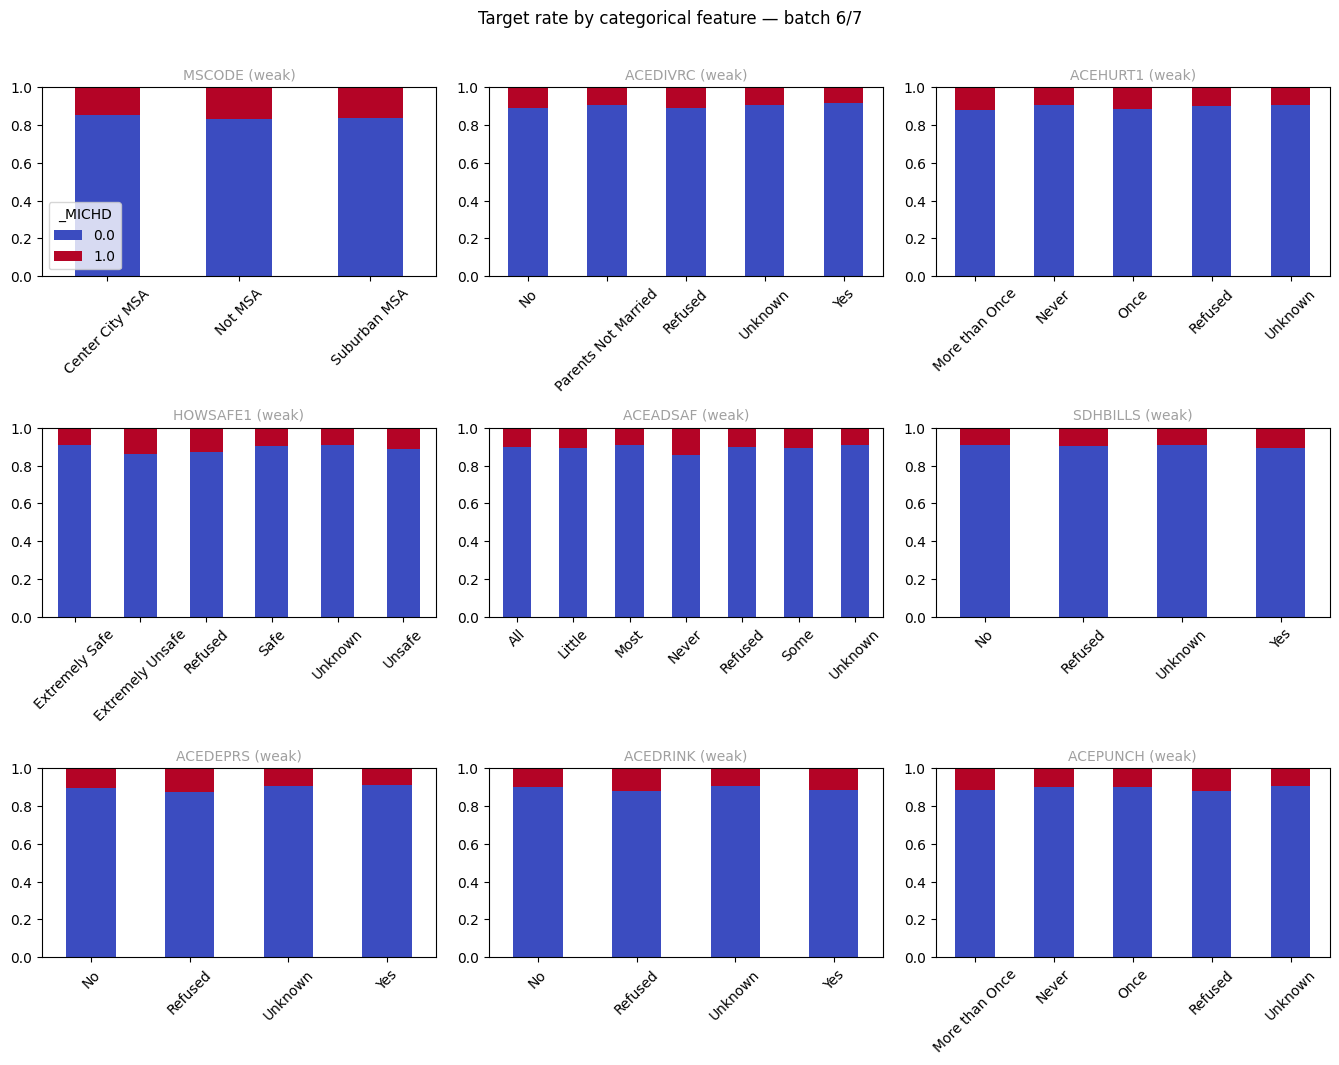

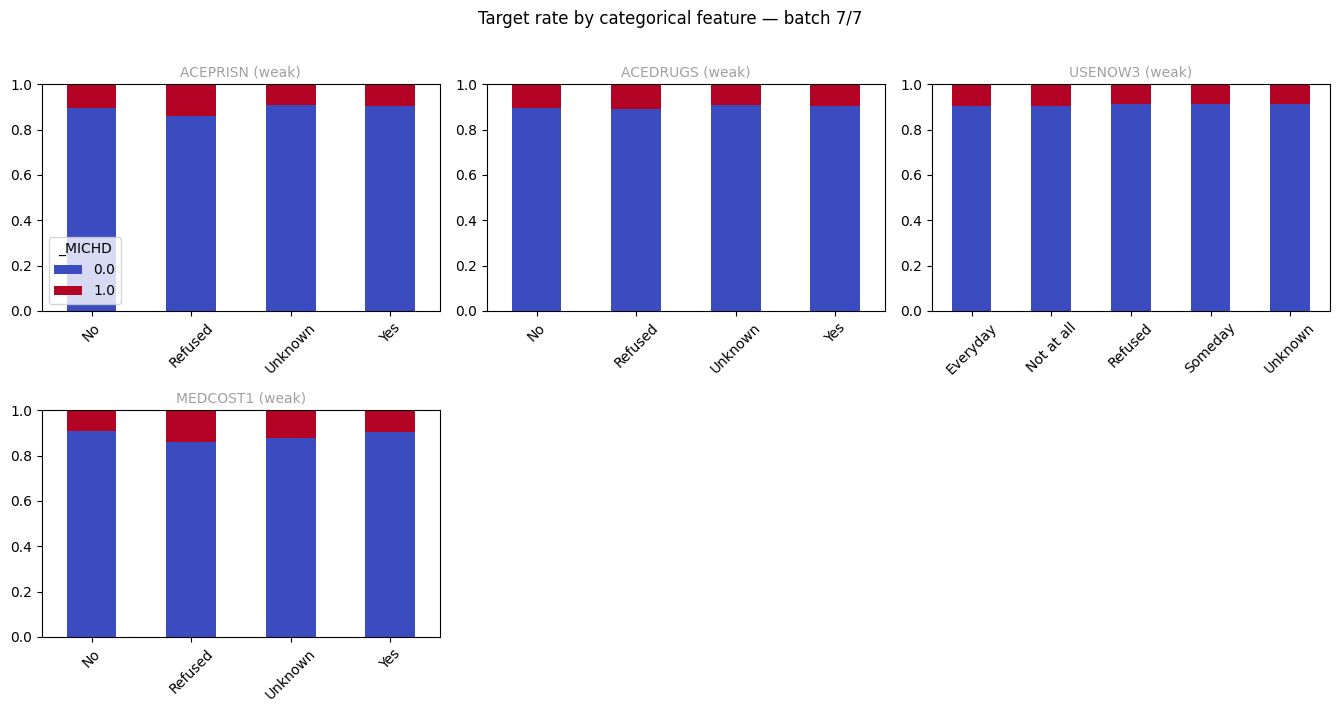

,feature,cramers_v,p_value,sig_p,sig_cv,sig_cat
44,_RFHLTH,0.209266,0.000000e+00,True,True,both
18,DIFFWALK,0.202196,0.000000e+00,True,True,both
4,CVDSTRK3,0.201371,0.000000e+00,True,True,both
0,PRIMINS2,0.193921,0.000000e+00,True,True,both
7,CHCCOPD3,0.183726,0.000000e+00,True,True,both
11,DIABETE4,0.180588,0.000000e+00,True,True,both
10,HAVARTH4,0.176755,0.000000e+00,True,True,both
9,CHCKDNY2,0.159443,0.000000e+00,True,True,both
23,PNEUVAC4,0.159317,0.000000e+00,True,True,both
12,MARITAL,0.140185,0.000000e+00,True,True,both


In [11]:
# Multi-class Categorical Features Analysis
cat_results = []

# Loop through your multi-class categorical columns instead of binary
for col in categorical_cols:
    clean = df[[col, TARGET]].dropna()
    ct = pd.crosstab(clean[col], clean[TARGET])
    
    # chi2_contingency and cramers_v natively support multi-class categories
    chi2, pval, _, _ = chi2_contingency(ct)
    cv = cramers_v(clean[col], clean[TARGET])
    
    cat_results.append({"feature": col, "cramers_v": cv, "p_value": pval})

cat_df = pd.DataFrame(cat_results).sort_values("cramers_v", ascending=False)
cat_df["sig_p"] = cat_df["p_value"] <= P_THRESHOLD
cat_df["sig_cv"] = cat_df["cramers_v"] >= CV_THRESHOLD

# 4-way classification
def _sig_category(row):
    if row["sig_p"] and row["sig_cv"]: return "both"
    if row["sig_p"]: return "p_only"
    if row["sig_cv"]: return "cv_only"
    return "neither"

cat_df["sig_cat"] = cat_df.apply(_sig_category, axis=1)
sig_cat_feats = cat_df[cat_df["sig_cat"] == "both"]["feature"].tolist()
all_cat_feats = cat_df["feature"].tolist()

# Color + label lookup (Reused from your setup)
CAT_COLOR = {
    "both": "#1D9E75",    # green: strong signal
    "p_only": "#A8D8C0",  # mint: significant but weak effect
    "cv_only": "#F4A736", # amber: notable effect, unreliable p
    "neither": "#B0B0B0", # grey: nothing
}
CAT_LABEL = {
    "both": f"p <= {P_THRESHOLD} & V >= {CV_THRESHOLD}",
    "p_only": f"p <= {P_THRESHOLD} only (weak effect)",
    "cv_only": f"V >= {CV_THRESHOLD} only (unreliable p)",
    "neither": "Not significant",
}

# Ranking chart
feat_idx = cat_df.set_index("feature")
plot_df = feat_idx.loc[all_cat_feats, "cramers_v"].sort_values()
colors = [CAT_COLOR[feat_idx.loc[f, "sig_cat"]] for f in plot_df.index]

fig, ax = plt.subplots(figsize=(8, max(3, len(all_cat_feats) * 0.4 + 1)))
plot_df.plot(kind="barh", ax=ax, color=colors)
ax.axvline(CV_THRESHOLD, color="#F4A736", linewidth=1, linestyle="--", label=f"V = {CV_THRESHOLD}")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Cramér's V")
ax.set_title(f"Categorical features — association with {TARGET} "
             f"({len(sig_cat_feats)}/{len(all_cat_feats)} fully significant)")

present_cats = cat_df["sig_cat"].unique()
legend_patches = [Patch(color=CAT_COLOR[c], label=CAT_LABEL[c]) for c in ["both", "p_only", "cv_only", "neither"] if c in present_cats]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Stacked bar grids
CAT_SUFFIX = {"both": "", "p_only": " (weak)", "cv_only": " (p?)", "neither": " (ns)"}

def cat_plot_fn(col, j, ax):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")
    # MODIFICATION: Changed rot=0 to rot=45 so multi-class category labels don't overlap
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm", legend=(j == 0), rot=45) 
    
    cat = feat_idx.loc[col, "sig_cat"]
    color = CAT_COLOR[cat] if cat == "both" else "#A0A0A0"
    ax.set_title(f"{col}{CAT_SUFFIX[cat]}", fontsize=10, color=color)
    ax.set_ylim(0, 1)
    ax.set_xlabel("")

# Call plot_chunks using the new categorical features list
plot_chunks(all_cat_feats, cat_plot_fn, "Target rate by categorical feature — batch {}/{}")

cat_df

### Significance Testing & Effect Size Estimation on Continuous Variables vs\. \_MICHD

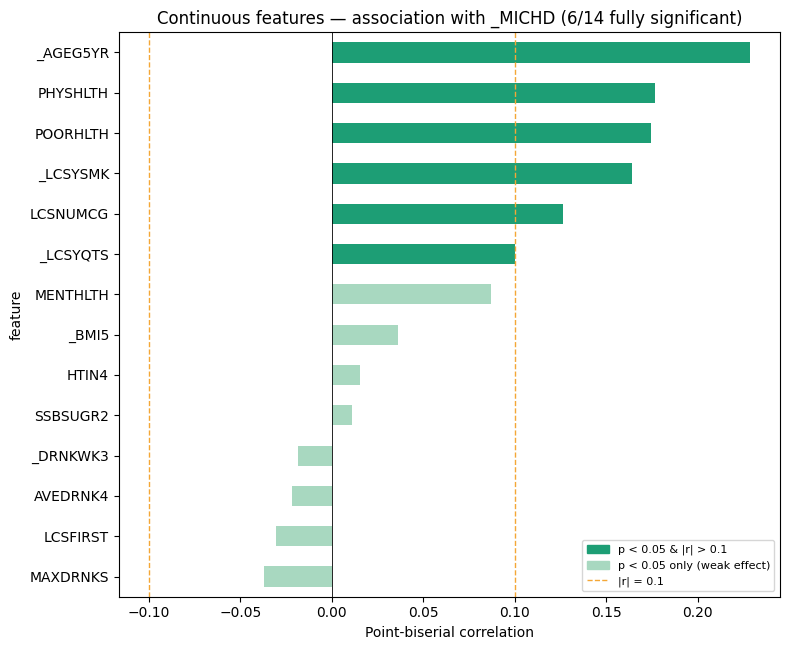

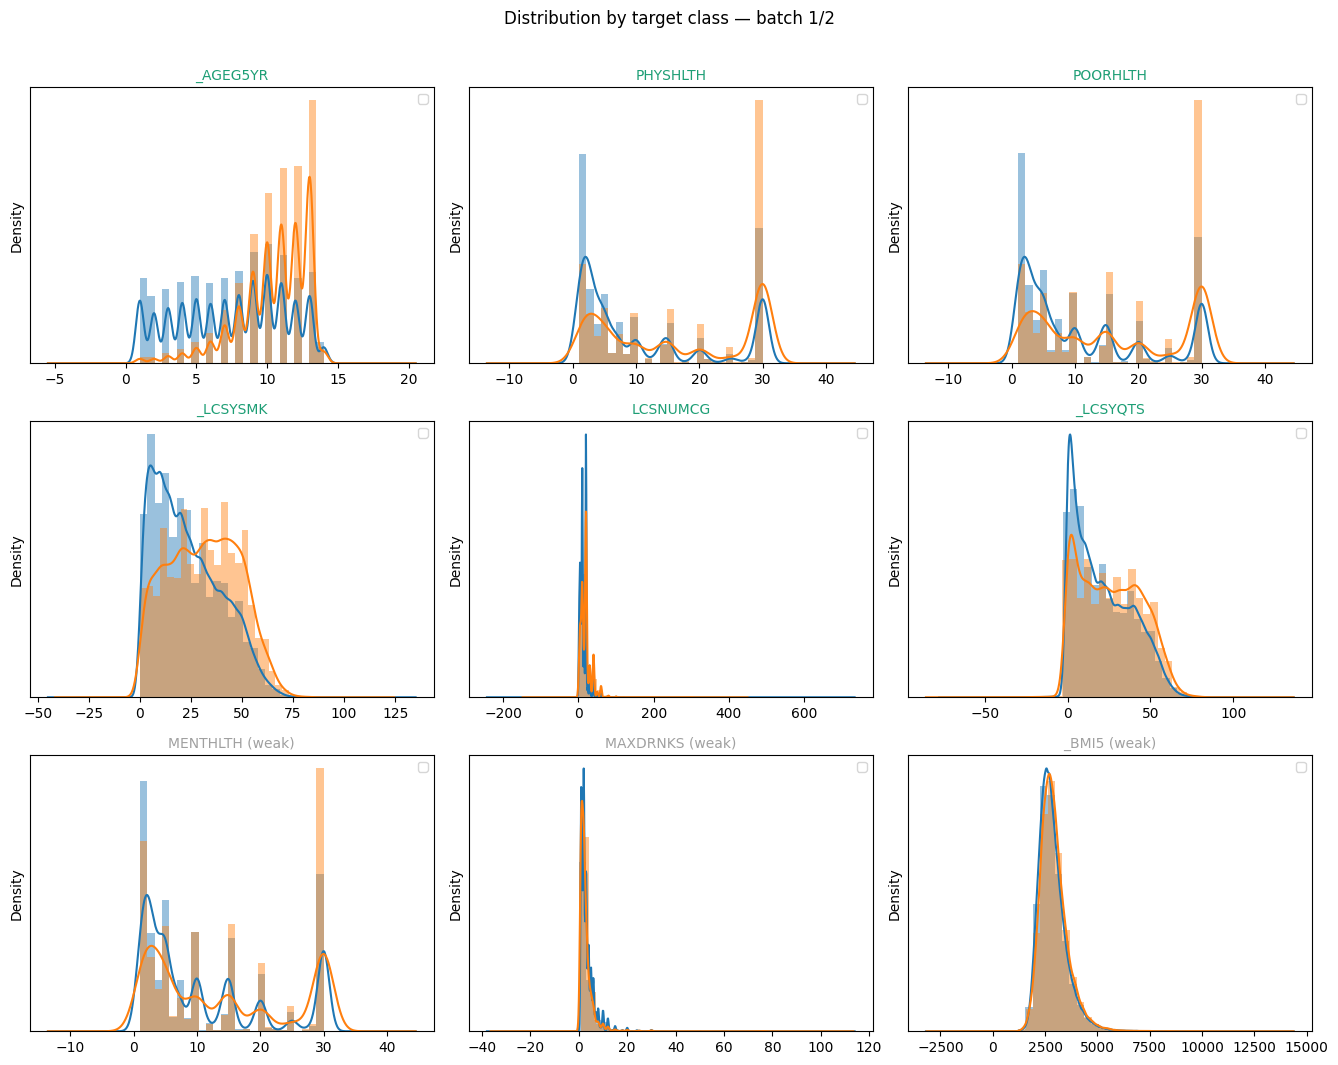

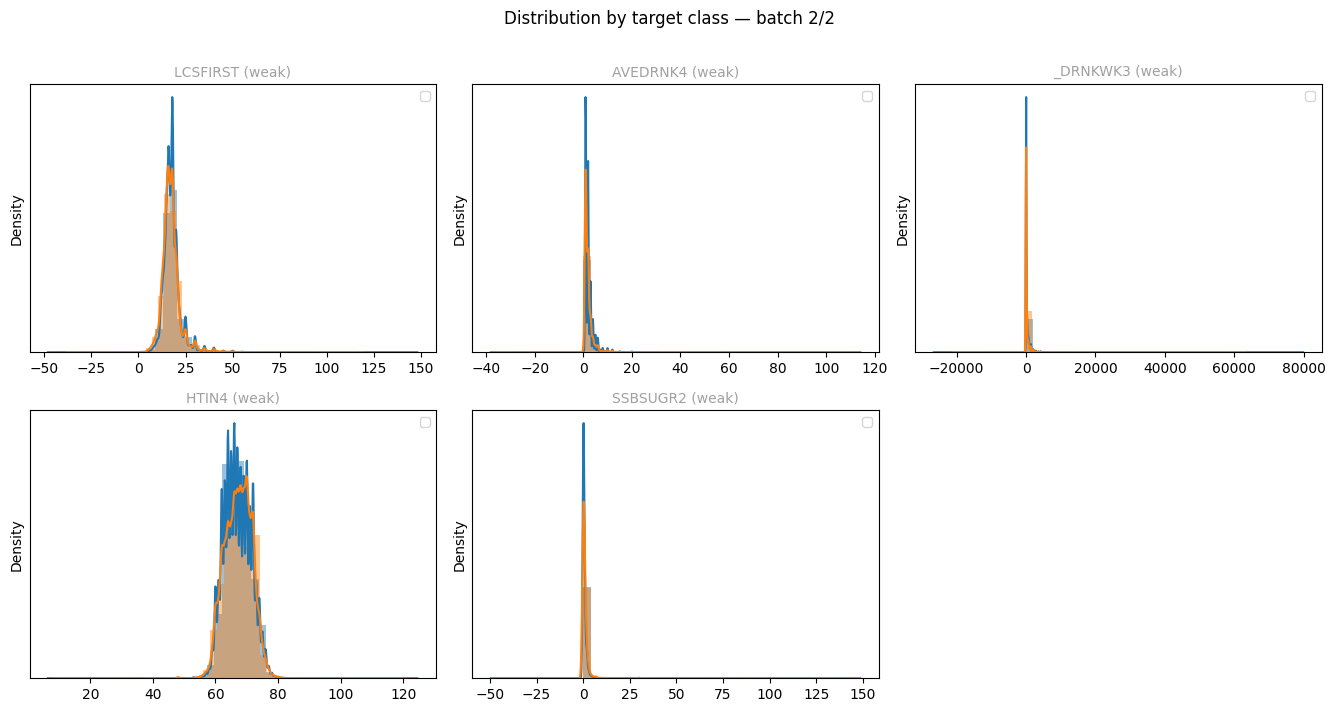

In [13]:
# Continuous Features

cont_results = []
for col in continuous_cols:
    clean = df[[col, TARGET]].dropna()
    corr, _ = pointbiserialr(clean[col], clean[TARGET])
    g0, g1  = clean[clean[TARGET]==0][col], clean[clean[TARGET]==1][col]
    _, pval = mannwhitneyu(g0, g1, alternative="two-sided")
    cont_results.append({"feature": col, "pb_corr": corr,
                         "abs_corr": abs(corr), "p_mw": pval})

cont_df = pd.DataFrame(cont_results).sort_values("abs_corr", ascending=False)
cont_df["sig_p"]  = cont_df["p_mw"]     < P_THRESHOLD
cont_df["sig_cv"] = cont_df["abs_corr"] > CORR_THRESHOLD

cont_df["sig_cat"] = cont_df.apply(_sig_category, axis=1)

sig_cont = cont_df[cont_df["sig_cat"] == "both"]["feature"].tolist()
all_cont = cont_df["feature"].tolist()

CONT_CAT_LABEL = {
    "both":    f"p < {P_THRESHOLD} & |r| > {CORR_THRESHOLD}",
    "p_only":  f"p < {P_THRESHOLD} only (weak effect)",
    "cv_only": f"|r| > {CORR_THRESHOLD} only (unreliable p)",
    "neither": "Not significant",
}

# ranking chart
feat_idx_c = cont_df.set_index("feature")
plot_df_c  = feat_idx_c.loc[all_cont, "pb_corr"].sort_values()
colors_c   = [CAT_COLOR[feat_idx_c.loc[f, "sig_cat"]] for f in plot_df_c.index]

fig, ax = plt.subplots(figsize=(8, max(3, len(all_cont) * 0.4 + 1)))
plot_df_c.plot(kind="barh", ax=ax, color=colors_c)
ax.axvline(0,                color="black",   linewidth=0.6)
ax.axvline( CORR_THRESHOLD,  color="#F4A736", linewidth=1, linestyle="--")
ax.axvline(-CORR_THRESHOLD,  color="#F4A736", linewidth=1, linestyle="--")
ax.set_xlabel("Point-biserial correlation")
ax.set_title(f"Continuous features — association with {TARGET} "
             f"({len(sig_cont)}/{len(all_cont)} fully significant)")

present_cats_c   = cont_df["sig_cat"].unique()
legend_patches_c = [Patch(color=CAT_COLOR[c], label=CONT_CAT_LABEL[c])
                    for c in ["both", "p_only", "cv_only", "neither"] if c in present_cats_c]
legend_patches_c.append(Line2D([0], [0], color="#F4A736", linewidth=1,
                                linestyle="--", label=f"|r| = {CORR_THRESHOLD}"))
ax.legend(handles=legend_patches_c, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# KDE overlay grids
classes    = sorted(df[TARGET].unique())
cmap       = plt.colormaps["tab10"]
kde_colors = [cmap(i) for i in range(len(classes))]

def cont_plot_fn(col, j, ax):
    for k, cls in enumerate(classes):
        subset = df[df[TARGET] == cls][col].dropna()
        if len(subset) < 2:
            continue
        ax.hist(subset, bins=25, alpha=0.45, color=kde_colors[k], density=True,
                label="_nolegend_")
        try:
            subset.plot.kde(ax=ax, color=kde_colors[k], linewidth=1.5,
                            label="_nolegend_")
        except Exception:
            pass

    cat   = feat_idx_c.loc[col, "sig_cat"]
    color = CAT_COLOR[cat] if cat == "both" else "#A0A0A0"
    ax.set_title(f"{col}{CAT_SUFFIX[cat]}", fontsize=10, color=color)
    ax.set_yticks([])

    handles = [Patch(color=kde_colors[k], alpha=0.6, label=f"{TARGET}={cls}")
            for k, cls in enumerate(classes)]
    ax.legend(handles=[h for h in handles if not h.get_label().startswith("_")], fontsize=9)

plot_chunks(all_cont, cont_plot_fn,
            "Distribution by target class — batch {}/{}")

In [14]:
cont_df

,feature,pb_corr,abs_corr,p_mw,sig_p,sig_cv,sig_cat
8,_AGEG5YR,0.228582,0.228582,0.000000e+00,True,True,both
0,PHYSHLTH,0.176781,0.176781,0.000000e+00,True,True,both
2,POORHLTH,0.174363,0.174363,0.000000e+00,True,True,both
11,_LCSYSMK,0.164334,0.164334,0.000000e+00,True,True,both
4,LCSNUMCG,0.126650,0.126650,0.000000e+00,True,True,both
12,_LCSYQTS,0.100238,0.100238,6.320890e-237,True,True,both
1,MENTHLTH,0.086872,0.086872,1.193637e-239,True,False,p_only
6,MAXDRNKS,-0.036866,0.036866,4.475573e-165,True,False,p_only
10,_BMI5,0.036412,0.036412,1.870568e-160,True,False,p_only
3,LCSFIRST,-0.030462,0.030462,1.414677e-64,True,False,p_only


### Summary, Final Selection of Features based on Significance and Effect Size

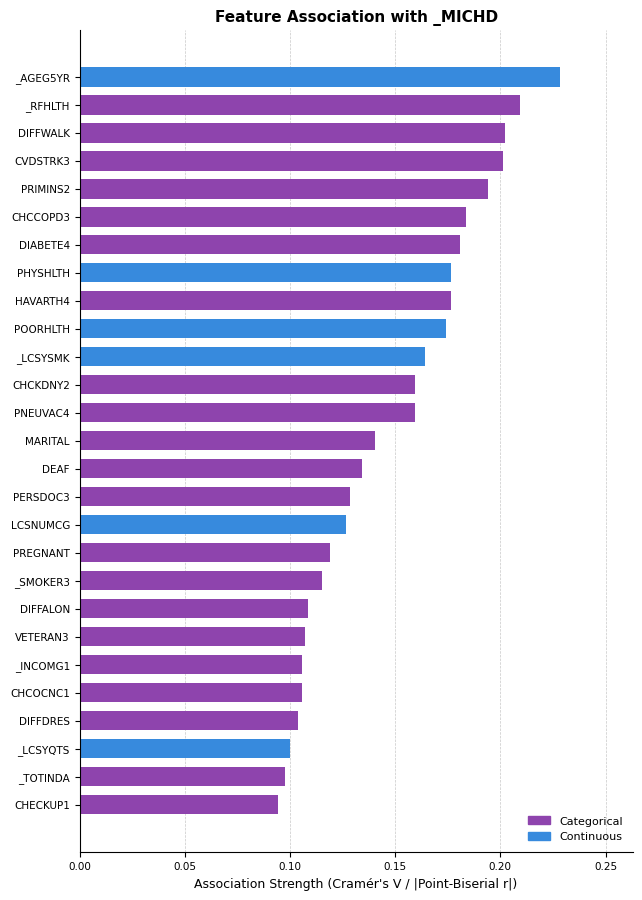

,feature,score,p_val,type
3,CHECKUP1,0.094358,0.000000e+00,categorical
46,_TOTINDA,0.097758,0.000000e+00,categorical
12,_LCSYQTS,0.100238,6.320890e-237,continuous
19,DIFFDRES,0.103791,0.000000e+00,categorical
6,CHCOCNC1,0.105672,0.000000e+00,categorical
51,_INCOMG1,0.105740,0.000000e+00,categorical
13,VETERAN3,0.107073,0.000000e+00,categorical
20,DIFFALON,0.108581,0.000000e+00,categorical
52,_SMOKER3,0.115173,0.000000e+00,categorical
14,PREGNANT,0.118943,0.000000e+00,categorical


In [42]:
# Summary
cat_top = (cat_df[cat_df["sig_cat"].isin(["both"])]
           [["feature", "cramers_v", "p_value"]]
           .rename(columns={"cramers_v": "score", "p_value": "p_val"})
           .assign(type="categorical"))

cont_top = (cont_df[cont_df["sig_cat"].isin(["both"])]
            [["feature", "abs_corr", "p_mw"]]
            .rename(columns={"abs_corr": "score", "p_mw": "p_val"})
            .assign(type="continuous"))

summary = (pd.concat([cat_top, cont_top])
           .sort_values("score", ascending=True))

colors_map = {"categorical": "#8E44AD", "continuous": "#378ADD"}
bar_colors = summary["type"].map(colors_map)

fig, ax = plt.subplots(figsize=(7, len(summary) * 0.35))
bars = ax.barh(summary["feature"], summary["score"], color=bar_colors, height=0.7)

ax.set_xlabel("Association Strength (Cramér's V / |Point-Biserial r|)", fontsize=9)
ax.set_title(f"Feature Association with {TARGET}", fontsize=11, fontweight="bold")
ax.tick_params(axis='y', labelsize=7.5)
ax.tick_params(axis='x', labelsize=7.5)
ax.set_xlim(0, summary["score"].max() * 1.15)
ax.xaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    handles=[Patch(color=v, label=k.capitalize()) for k, v in colors_map.items()],
    fontsize=8, frameon=False, loc="lower right"
)

plt.subplots_adjust(left=0.18, right=0.97, top=0.95, bottom=0.08)
plt.show()

summary

### Correlation Matrix on the Final Column List to Spot Multicollinearity

High-correlation pairs (>0.7):


,feature_a,feature_b,metric,value,p_value


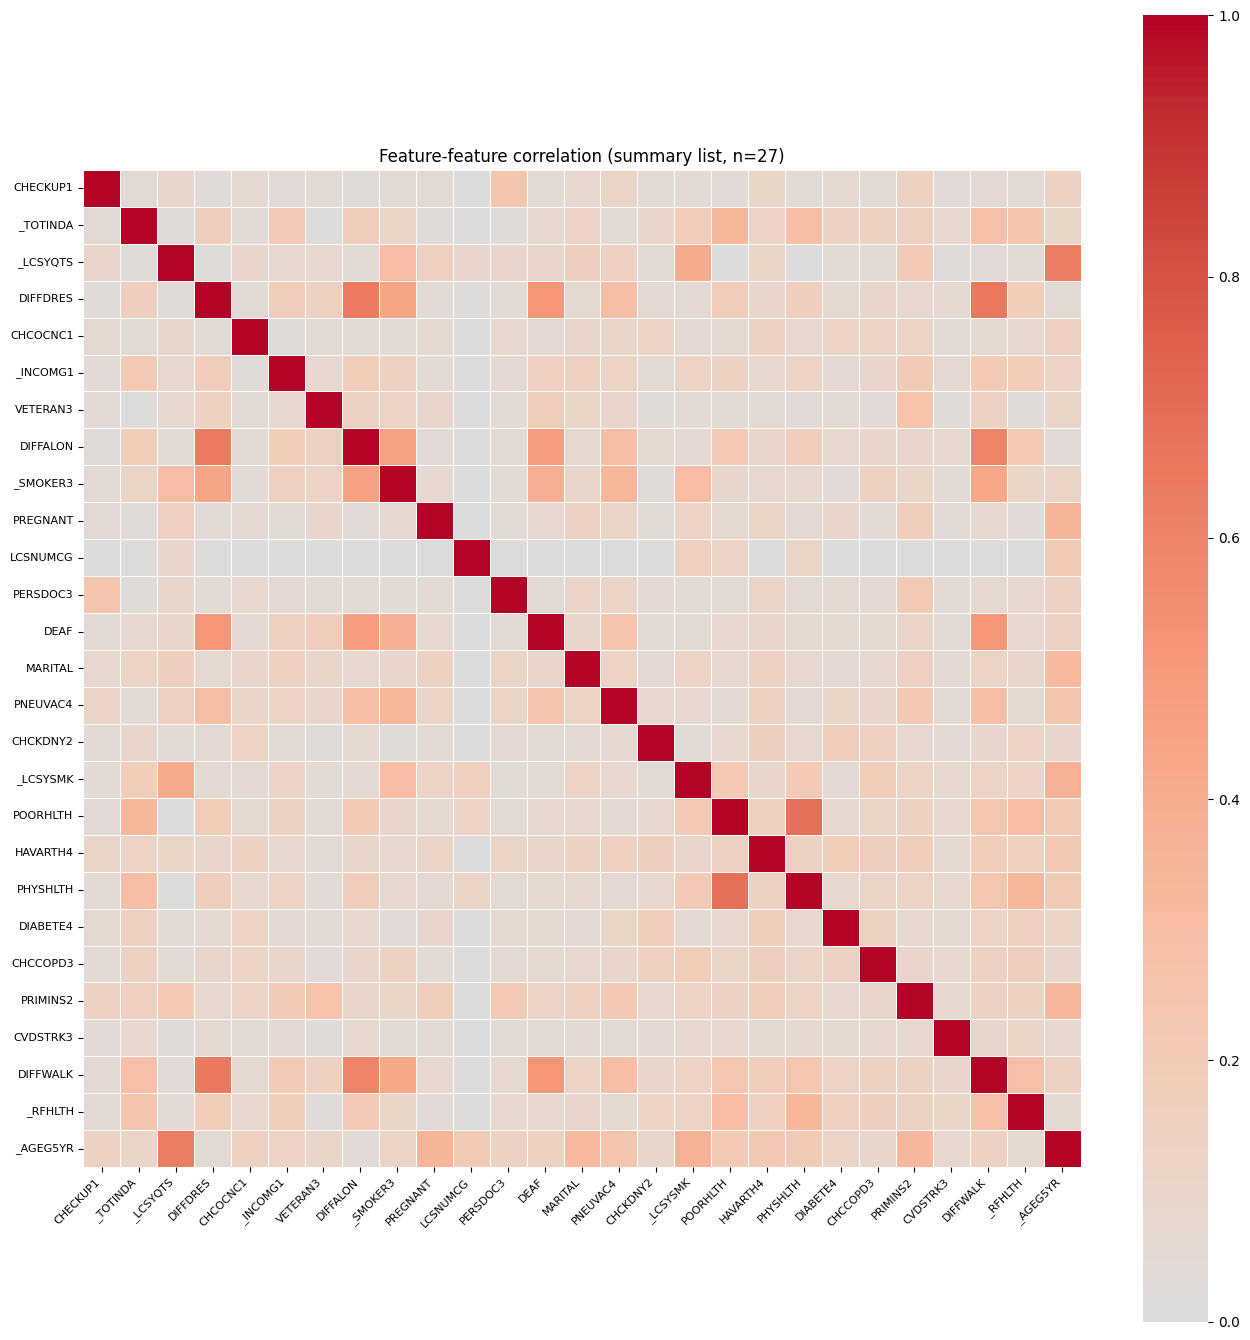

In [44]:
summary_features = summary["feature"].tolist()
summary_cat  = [f for f in summary_features if f in categorical_cols]
summary_cont = [f for f in summary_features if f in continuous_cols]

# categorical-categorical: Cramer's V
cat_corr_results = []
for i, a in enumerate(summary_cat):
    for b in summary_cat[i+1:]:
        clean = df[[a, b]].dropna()
        ct    = pd.crosstab(clean[a], clean[b])
        cv    = cramers_v(clean[a], clean[b])
        _, pval, _, _ = chi2_contingency(ct)
        cat_corr_results.append({"feature_a": a, "feature_b": b,
                                  "metric": "cramers_v", "value": cv, "p_value": pval})

# continuous-continuous: Pearson r
cont_corr_results = []
for i, a in enumerate(summary_cont):
    for b in summary_cont[i+1:]:
        clean = df[[a, b]].dropna()
        r, pval = pearsonr(clean[a], clean[b])
        cont_corr_results.append({"feature_a": a, "feature_b": b,
                                   "metric": "pearson_r", "value": abs(r), "p_value": pval})

# categorical-continuous: Cramér's V
mixed_corr_results = []
for a in summary_cat:
    for b in summary_cont:
        clean = df[[a, b]].dropna()
        clean[b] = pd.cut(clean[b], bins=5).astype(str)  # bin continuous into ordinal categories
        ct = pd.crosstab(clean[a], clean[b])
        cv = cramers_v(clean[a], clean[b])
        _, pval, _, _ = chi2_contingency(ct)
        mixed_corr_results.append({"feature_a": a, "feature_b": b,
                                    "metric": "cramers_v", "value": cv, "p_value": pval})

pair_df = (pd.concat([pd.DataFrame(r) for r in
                      [cat_corr_results, cont_corr_results, mixed_corr_results]
                      if r])
           .sort_values("value", ascending=False)
           .reset_index(drop=True))

PAIR_THRESHOLD = 0.7
pair_df["high_corr"] = pair_df["value"] > PAIR_THRESHOLD

print(f"High-correlation pairs (>{PAIR_THRESHOLD}):")
display(pair_df[pair_df["high_corr"]][["feature_a", "feature_b", "metric", "value", "p_value"]])

corr_matrix = pd.DataFrame(index=summary_features, columns=summary_features, dtype=float)
np.fill_diagonal(corr_matrix.values, 1.0)

for _, row in pair_df.iterrows():
    corr_matrix.loc[row["feature_a"], row["feature_b"]] = row["value"]
    corr_matrix.loc[row["feature_b"], row["feature_a"]] = row["value"]

corr_matrix = corr_matrix.fillna(0)

fig, ax = plt.subplots(figsize=(max(8, len(summary_features) * 0.5),
                                max(6, len(summary_features) * 0.5)))
sns.heatmap(corr_matrix.astype(float), ax=ax, cmap="coolwarm", center=0,
            vmin=0, vmax=1, annot=len(summary_features) <= 20,
            fmt=".2f", linewidths=0.5, square=True,
            xticklabels=True, yticklabels=True)
ax.set_title(f"Feature-feature correlation (summary list, n={len(summary_features)})")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

### No significant multicollinearity detected in the final selection of features\. Below is the final selection\.

In [61]:
selected_features = summary['feature']
selected_features

3     CHECKUP1
46    _TOTINDA
12    _LCSYQTS
19    DIFFDRES
6     CHCOCNC1
51    _INCOMG1
13    VETERAN3
20    DIFFALON
52    _SMOKER3
14    PREGNANT
4     LCSNUMCG
1     PERSDOC3
15        DEAF
12     MARITAL
23    PNEUVAC4
9     CHCKDNY2
11    _LCSYSMK
2     POORHLTH
10    HAVARTH4
0     PHYSHLTH
11    DIABETE4
7     CHCCOPD3
0     PRIMINS2
4     CVDSTRK3
18    DIFFWALK
44     _RFHLTH
8     _AGEG5YR
Name: feature, dtype: object

In [63]:
with open("selected_features_v2.pkl", "wb") as f:
    pickle.dump(selected_features, f)

# Quick Random Forest to Evaluate if it Works

In [53]:
%pip install scikit-learn==1.5.2 imbalanced-learn==0.12.4


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [55]:
# imports
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve,
                                      precision_recall_curve, average_precision_score)
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from imblearn.under_sampling   import RandomUnderSampler
import matplotlib.gridspec as gridspec

Before resampling — 0: 328,101 | 1: 33,870
After resampling — 0: 33,870 | 1: 33,870
Test (untouched) — 0: 82,025 | 1: 8,468

CV AUC (5-fold): 0.8313 ± 0.0040

Test AUC: 0.8323
Test Avg Precision: 0.3481

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     82025
         1.0       0.22      0.80      0.34      8468

    accuracy                           0.72     90493
   macro avg       0.60      0.75      0.58     90493
weighted avg       0.90      0.72      0.77     90493

/tmp/ipykernel_109/2658177454.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


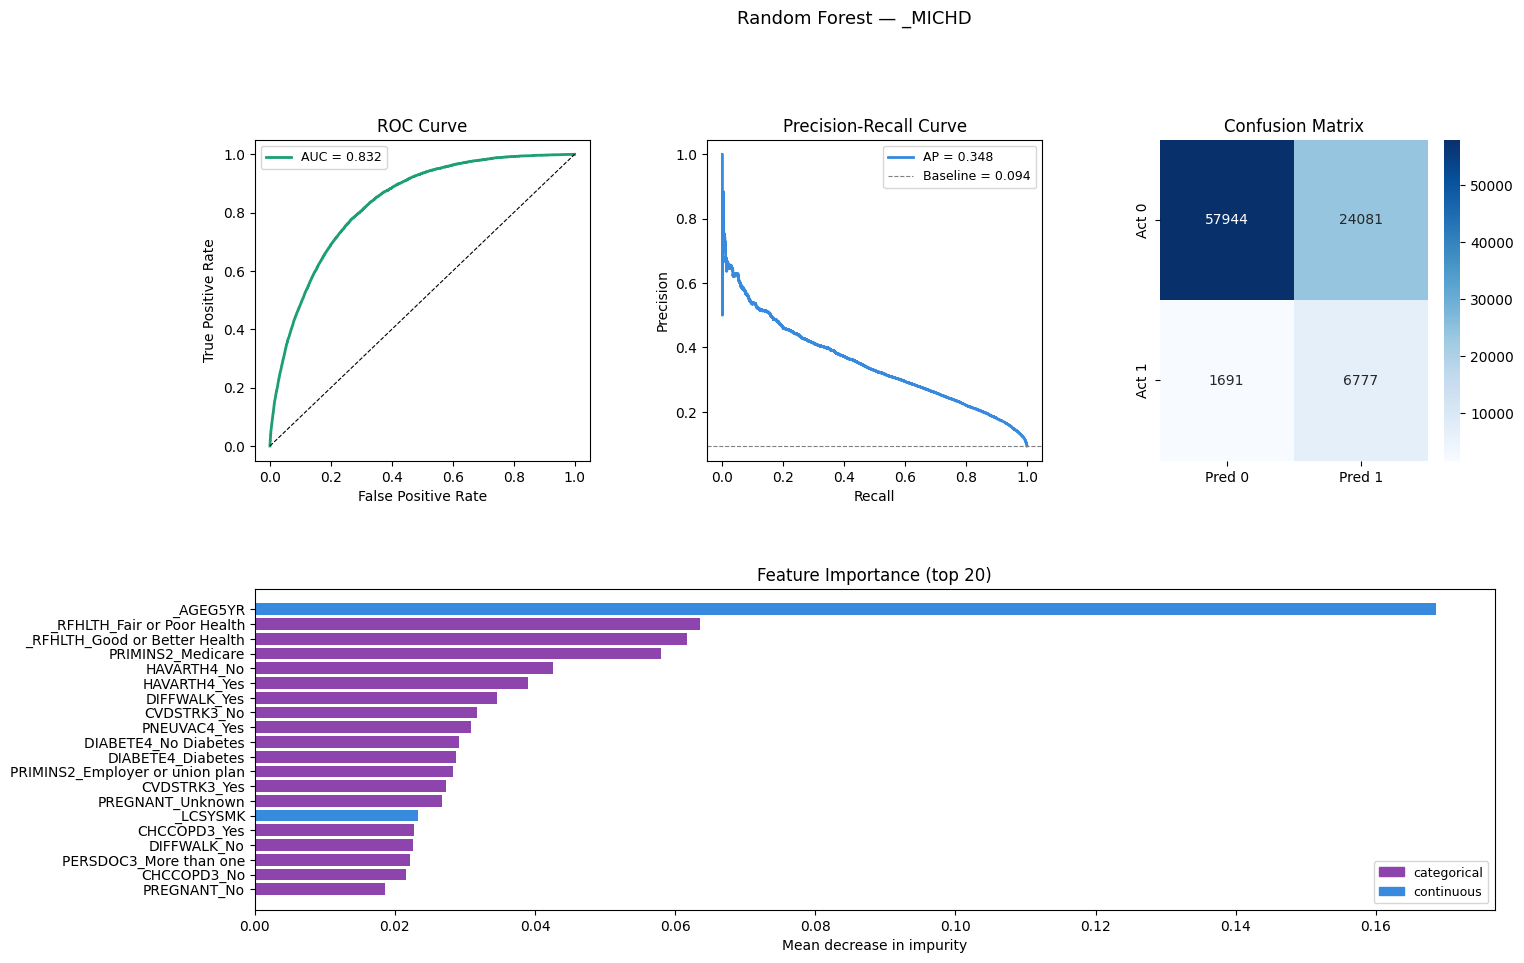

In [59]:
# config
FEATURES = summary["feature"].tolist()
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
RF_PARAMS = {
    "n_estimators": 1000,
    "max_depth": None,
    "min_samples_leaf": 20,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

df = df[df[TARGET].notna()]

# data prep
model_df = df[FEATURES + [TARGET]].copy()
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# undersample majority class on train only
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"Before resampling — 0: {(y_train==0).sum():,} | 1: {(y_train==1).sum():,}")
print(f"After resampling — 0: {(y_train_res==0).sum():,} | 1: {(y_train_res==1).sum():,}")
print(f"Test (untouched) — 0: {(y_test==0).sum():,} | 1: {(y_test==1).sum():,}")

# Preprocessing pipeline
cat_features = [f for f in FEATURES if f in categorical_cols]
cont_features = [f for f in FEATURES if f in continuous_cols]

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

cont_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("categorical", cat_transformer, cat_features),
    ("continuous", cont_transformer, cont_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(**RF_PARAMS)),
])

# fit
pipeline.fit(X_train_res, y_train_res)

# cross-validated AUC (on resampled train)
cv_auc = cross_val_score(pipeline, X_train_res, y_train_res, cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE), scoring="roc_auc", n_jobs=-1)
print(f"\nCV AUC ({CV_FOLDS}-fold): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# test set evaluation
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_prob)
test_ap = average_precision_score(y_test, y_prob)

print(f"\nTest AUC: {test_auc:.4f}")
print(f"Test Avg Precision: {test_ap:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Extract transformed feature names
transformed_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

def get_feature_type(name):
    if name.startswith("categorical__"): return "categorical"
    return "continuous"

# plots
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ROC curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color="#1D9E75", lw=2, label=f"AUC = {test_auc:.3f}")
ax1.plot([0,1], [0,1], "k--", lw=0.8)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve"); ax1.legend(fontsize=9)

# Precision-Recall curve
ax2 = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(rec, prec, color="#378ADD", lw=2, label=f"AP = {test_ap:.3f}")
ax2.axhline(y_test.mean(), color="grey", linestyle="--", lw=0.8, label=f"Baseline = {y_test.mean():.3f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve"); ax2.legend(fontsize=9)

# Confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3, xticklabels=[f"Pred {c}" for c in [0,1]], yticklabels=[f"Act {c}" for c in [0,1]])
ax3.set_title("Confusion Matrix")

# Feature importance (top 20)
ax4 = fig.add_subplot(gs[1, :])
rf_model = pipeline.named_steps["model"]

imp_df = pd.DataFrame({
    "feature": transformed_names,
    "importance": rf_model.feature_importances_
})
imp_df["type"] = imp_df["feature"].apply(get_feature_type)
imp_df["feature"] = imp_df["feature"].str.replace(r"^(categorical__|continuous__)", "", regex=True)

imp_df = imp_df.sort_values("importance", ascending=False).head(20)

colors_map = {
    "categorical": "#8E44AD",
    "continuous": "#378ADD"
}
imp_colors = imp_df["type"].map(colors_map).tolist()

ax4.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=imp_colors[::-1])
ax4.set_xlabel("Mean decrease in impurity")
ax4.set_title("Feature Importance (top 20)")
ax4.legend(handles=[Patch(color=v, label=k) for k, v in colors_map.items()], fontsize=9)

plt.suptitle(f"Random Forest — {TARGET}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88479c56-07bc-4e04-92b4-d8345dc226f4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>